# Visual Localizer GLM Results

Set the variables in the next cell, then run the notebook to visualize one first-level map.

In [4]:
from pathlib import Path

# Change these values
SUBJECT = "pp03"
MAP_TYPE = "contrast"  # "condition" or "contrast"
MAP_NAME = "visual_object-visual_scene"  # visual_object, visual_scene, visual_object-visual_scene, visual_scene-visual_object
STAT = "z_score"  # "z_score" or "effect_size"
FDR_CORRECTED = True
THRESHOLD = 2.3     # over written by saved threshold for FDR correction

# Usually leave these alone
TASK = "vislocalizer"
SPACE = "T1w"
RESULTS_DIR = Path("/gpfs/milgram/project/turk-browne/aa2842/auditory-objects-scenes-project/GLM/results")
FMRIPREP_DIR = Path("/gpfs/milgram/scratch60/turk-browne/aa2842/sandbox/auditory-object-scenes-data/objects_scenes_bids/derivatives")
BG_IMG = None  # Optional manual background image path; leave None to use subject T1w automatically

In [5]:
def format_subject(sub):
    sub = str(sub).replace("sub-", "")
    if not sub.startswith("pp"):
        sub = f"pp{sub}"
    return f"sub-{sub}"


def list_available_maps(results_dir, sub_bids):
    sub_dir = results_dir / "first_level_glm" / sub_bids
    if not sub_dir.exists():
        print(f"No results directory found for {sub_bids}: {sub_dir}")
        return []

    maps = sorted(sub_dir.glob("**/*.nii.gz"))
    for path in maps:
        print(path.relative_to(sub_dir))
    return maps


def find_bg_img(fmriprep_dir, sub_bids, space, bg_img=None):
    if bg_img is not None:
        return Path(bg_img)
    if space == "T1w":
        anat_path = fmriprep_dir / sub_bids / "anat" / f"{sub_bids}_desc-preproc_T1w.nii.gz"
        if anat_path.exists():
            return anat_path
    return None


sub_bids = format_subject(SUBJECT)

if FDR_CORRECTED:
    if STAT != "z_score":
        raise ValueError("FDR correction should only be used with z_score maps.")

    map_path = (
        RESULTS_DIR
        / "first_level_glm"
        / sub_bids
        / MAP_TYPE
        / MAP_NAME
        / f"{sub_bids}_task-{TASK}_{MAP_TYPE}-{MAP_NAME}_space-{SPACE}_stat-z_score_desc-fdr_alpha-0p05.nii.gz"
    )

    threshold_path = (
        RESULTS_DIR
        / "first_level_glm"
        / sub_bids
        / MAP_TYPE
        / MAP_NAME
        / f"{sub_bids}_task-{TASK}_{MAP_TYPE}-{MAP_NAME}_space-{SPACE}_stat-z_score_desc-fdr_alpha-0p05_threshold.txt"
    )

    if threshold_path.exists():
        with open(threshold_path, "r") as f:
            THRESHOLD = float(f.read())

else:
    map_path = (
        RESULTS_DIR
        / "first_level_glm"
        / sub_bids
        / MAP_TYPE
        / MAP_NAME
        / f"{sub_bids}_task-{TASK}_{MAP_TYPE}-{MAP_NAME}_space-{SPACE}_stat-{STAT}.nii.gz"
    )

bg_img = find_bg_img(FMRIPREP_DIR, sub_bids, SPACE, BG_IMG)

print(f"Looking for: {map_path}")
print(f"Background image: {bg_img}")

if not map_path.exists():
    print("\nRequested map was not found. Available maps:")
    list_available_maps(RESULTS_DIR, sub_bids)
    raise FileNotFoundError(map_path)

Looking for: /gpfs/milgram/project/turk-browne/aa2842/auditory-objects-scenes-project/GLM/results/first_level_glm/sub-pp03/contrast/visual_object-visual_scene/sub-pp03_task-vislocalizer_contrast-visual_object-visual_scene_space-T1w_stat-z_score_desc-fdr_alpha-0p05.nii.gz
Background image: /gpfs/milgram/scratch60/turk-browne/aa2842/sandbox/auditory-object-scenes-data/objects_scenes_bids/derivatives/sub-pp03/anat/sub-pp03_desc-preproc_T1w.nii.gz


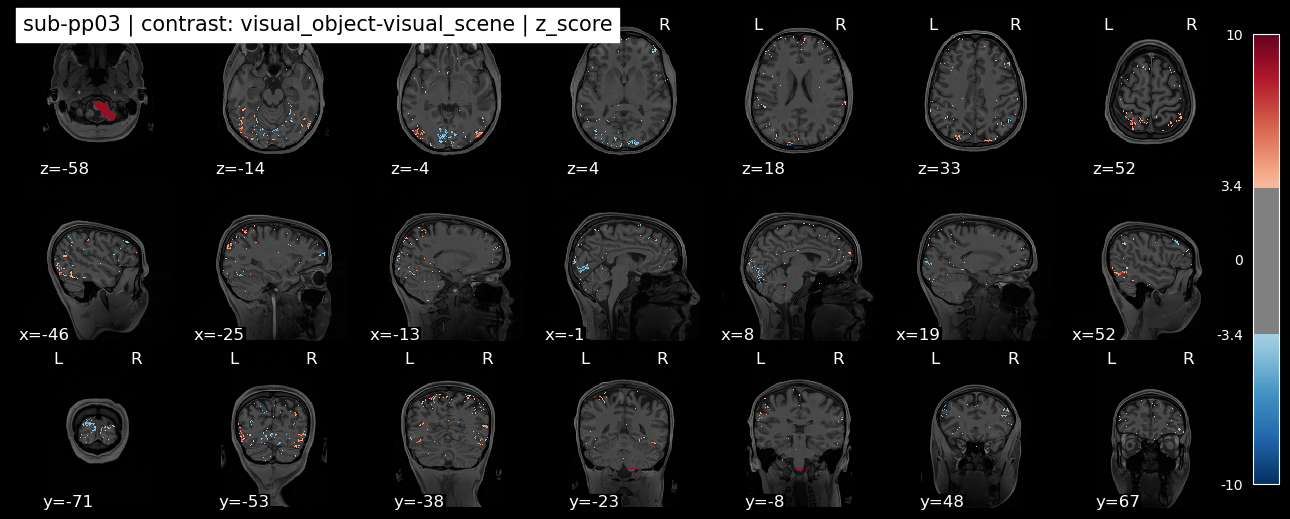

In [6]:
from nilearn import plotting

title = f"{sub_bids} | {MAP_TYPE}: {MAP_NAME} | {STAT}"

display = plotting.plot_stat_map(
    str(map_path),
    bg_img=str(bg_img) if bg_img is not None else None,
    title=title,
    threshold=THRESHOLD,
    display_mode="mosaic",
    cut_coords=None,
    colorbar=True,
)

plotting.show()

In [7]:
THRESHOLD

3.426952183796279